# Start SBI Dataset

This notebook prepares the new 512-row Battaglia y100/y102 dataset for `sbi`. It reads the combined cluster output NPZ, keeps the Sobol parameter rows, converts raw spectra to `log10(D_l)`, estimates the paired-lightcone scatter, and exposes `torch.float32` tensors ready for `inference.append_simulations(theta, x)`.


In [321]:
from matplotlib.ticker import LinearLocator, MaxNLocator
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import numpy as np

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from sbi.analysis import pairplot
    from sbi.analysis.plotting_classes import KdeOffDiagOptions
    from sbi.analysis.plotting_classes import (
        HistDiagOptions,
        HistOffDiagOptions,
        FigOptions,
        ScatterOffDiagOptions,
        ContourOffDiagOptions,
    )
    from sbi.inference import NPE
except ModuleNotFoundError:
    pairplot = None
    KdeOffDiagOptions = None
    HistDiagOptions = None
    HistOffDiagOptions = None
    FigOptions = None
    NPE = None


In [322]:
from sbi.analysis.plotting_classes import (
    FigOptions,
    HistDiagOptions,
    KdeDiagOptions,
    ScatterDiagOptions,
    ScatterOffDiagOptions,
    ContourOffDiagOptions,
    KdeOffDiagOptions,
    HistOffDiagOptions,
)


def _as_tensor(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu()
    return torch.as_tensor(x)


def _is_none_kind(kind):
    return kind is None or str(kind).lower() in ["none", "off", "empty", "blank"]


def _diag_options(kind, color, cmap, bins):
    kind = str(kind).lower()

    if kind == "hist":
        return HistDiagOptions(
            mpl_kwargs={
                "color": color,
                "bins": bins,
                "alpha": 0.45,
                "histtype": "stepfilled",
                "density": True,
            }
        )

    elif kind == "kde":
        return KdeDiagOptions(
            mpl_kwargs={
                "color": color,
                "alpha": 0.9,
            }
        )

    elif kind == "scatter":
        return ScatterDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 8,
                "alpha": 0.3,
            }
        )

    else:
        raise ValueError(
            f"Unsupported diagonal plot kind: {kind}. "
            "Use 'hist', 'kde', or 'scatter'."
        )


def _offdiag_options(
    kind,
    color,
    cmap,
    hidden=False,
    scatter_cmap=None,
    scatter_gradient=False,
    n_points=None,
):
    kind = str(kind).lower()

    if hidden:
        return ScatterOffDiagOptions(
            mpl_kwargs={
                "color": color,
                "s": 0,
                "alpha": 0.0,
            }
        )

    if kind == "scatter":
        if scatter_gradient:
            if n_points is None:
                raise ValueError("n_points is required for scatter_gradient=True.")

            scatter_kwargs = {
                "color": None,
                "c": np.linspace(0, 1, n_points),
                "cmap": scatter_cmap if scatter_cmap is not None else cmap,
                "s": 6,
                "alpha": 0.35,
                "rasterized": True,
            }
        else:
            scatter_kwargs = {
                "color": color,
                "s": 6,
                "alpha": 0.20,
                "rasterized": True,
            }

        return ScatterOffDiagOptions(mpl_kwargs=scatter_kwargs)

    elif kind == "contour":
        return ContourOffDiagOptions(
            mpl_kwargs={
                "colors": color,
                "alpha": 0.9,
            },
            levels=[0.68, 0.95],
        )

    elif kind == "kde":
        return KdeOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
                "alpha": 0.8,
            }
        )

    elif kind == "hist":
        return HistOffDiagOptions(
            mpl_kwargs={
                "cmap": cmap,
            }
        )

    else:
        raise ValueError(
            f"Unsupported off-diagonal plot kind: {kind}. "
            "Use 'scatter', 'contour', 'kde', 'hist', or 'none'."
        )

def sbi_pairplot(
    samples,
    param_names,
    true_values=None,
    sample_labels=None,
    colors=None,
    cmaps=None,
    limits=None,
    subset=None,
    diag="hist",
    upper="contour",
    lower="scatter",
    bins=40,
    figsize=None,
    title=None,
    savepath=None,
    scatter_cmap=None,
    scatter_gradient=False,
    diag_param_labels=True,
):
    """
    Flexible pairplot wrapper for sbi posterior samples.

    Parameters
    ----------
    samples:
        Tensor/array of shape (N, ndim), or list of such arrays.
    param_names:
        List of parameter names.
    true_values:
        Optional fiducial/true parameter vector with shape (ndim,).
    sample_labels:
        Optional labels for multiple posterior sample sets.
    colors:
        Optional list of colors, one per sample set.
    cmaps:
        Optional list of colormaps, one per sample set.
    limits:
        Optional axis limits passed to sbi.analysis.pairplot.
    subset:
        Optional subset of parameters to plot, e.g. [0, 2, 4].
    diag:
        'hist', 'kde', or 'scatter'.
    upper:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    lower:
        'scatter', 'contour', 'kde', 'hist', or 'none'.
    """

    from matplotlib.ticker import LinearLocator as _LinearLocator

    # Allow one dataset or multiple datasets
    if not isinstance(samples, (list, tuple)):
        samples = [samples]

    samples = [_as_tensor(s) for s in samples]
    n_sets = len(samples)

    ndim = samples[0].shape[1]

    for s in samples:
        if s.ndim != 2:
            raise ValueError("Each sample set must have shape (N, ndim).")
        if s.shape[1] != ndim:
            raise ValueError("All sample sets must have the same number of parameters.")

    if len(param_names) != ndim:
        raise ValueError(
            f"param_names has length {len(param_names)}, but samples have ndim={ndim}."
        )

    if colors is None:
        colors = [f"C{i}" for i in range(n_sets)]

    if cmaps is None:
        default_cmaps = ["Blues", "Oranges", "Greens", "Purples", "Greys"]
        cmaps = [default_cmaps[i % len(default_cmaps)] for i in range(n_sets)]

    if sample_labels is None:
        sample_labels = [f"samples {i}" for i in range(n_sets)]

    if len(colors) != n_sets:
        raise ValueError("colors must have one entry per sample set.")

    if len(cmaps) != n_sets:
        raise ValueError("cmaps must have one entry per sample set.")

    if len(sample_labels) != n_sets:
        raise ValueError("sample_labels must have one entry per sample set.")

    points = None
    point_labels = []
    if true_values is not None:
        points = _as_tensor(true_values)
        if points.ndim == 1:
            points = points[None, :]
        point_labels = [r"$\theta_\mathrm{true}$"]

    hide_upper = _is_none_kind(upper)
    hide_lower = _is_none_kind(lower)

    # sbi needs a valid plot type, so use invisible scatter internally.
    upper_for_pairplot = "scatter" if hide_upper else str(upper).lower()
    lower_for_pairplot = "scatter" if hide_lower else str(lower).lower()

    diag_kwargs = [
        _diag_options(diag, colors[i], cmaps[i], bins)
        for i in range(n_sets)
    ]

    upper_kwargs = [
        _offdiag_options(
            upper_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_upper,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and upper_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    lower_kwargs = [
        _offdiag_options(
            lower_for_pairplot,
            colors[i],
            cmaps[i],
            hidden=hide_lower,
            scatter_cmap=scatter_cmap,
            scatter_gradient=scatter_gradient and lower_for_pairplot == "scatter",
            n_points=samples[i].shape[0],
        )
        for i in range(n_sets)
    ]

    if figsize is None:
        ndim_plot = len(subset) if subset is not None else ndim
        figsize = (2.4 * ndim_plot, 2.4 * ndim_plot)

    fig, axes = pairplot(
        samples,
        points=points,
        labels=param_names,
        limits=limits,
        subset=subset,
        diag=[str(diag).lower()] * n_sets,
        upper=[upper_for_pairplot] * n_sets,
        lower=[lower_for_pairplot] * n_sets,
        diag_kwargs=diag_kwargs,
        upper_kwargs=upper_kwargs,
        lower_kwargs=lower_kwargs,
        figsize=figsize,
        fig_kwargs=FigOptions(
            legend=True,
            samples_labels=sample_labels,
            samples_colors=colors,
            points_labels=point_labels,
            points_colors=["k"],
            points_offdiag={"marker": "+", "markersize": 14},
            points_diag={"marker": "+", "markersize": 14},
            title=title,
        ),
    )

    # Remove upper/lower triangle if requested
    axes_arr = np.asarray(axes)

    if axes_arr.ndim == 2:
        ndim_plot = axes_arr.shape[0]

        if hide_lower:
            for i in range(ndim_plot):
                for j in range(i):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

        if hide_upper:
            for i in range(ndim_plot):
                for j in range(i + 1, ndim_plot):
                    axes_arr[i, j].clear()
                    axes_arr[i, j].set_axis_off()

    # Fix labels when one triangle is hidden.
    # sbi normally labels mostly outer axes, which may have been hidden.
    if diag_param_labels and axes_arr.ndim == 2:
        if subset is None:
            plotted_param_names = list(param_names)
        else:
            plotted_param_names = [param_names[i] for i in subset]

        for i, name in enumerate(plotted_param_names):
            ax = axes_arr[i, i]
            ax.set_xlabel(name)
            ax.set_title(name)

    if axes_arr.ndim == 2:
        for ax in axes_arr.ravel():
            if not ax.axison:
                continue
            ax.xaxis.set_major_locator(_LinearLocator(3))
            ax.yaxis.set_major_locator(_LinearLocator(3))
            ax.tick_params(
                axis="both",
                which="major",
                labelsize=8,
                bottom=True,
                left=True,
                labelbottom=True,
                labelleft=True,
            )
            ax.tick_params(axis="x", which="major", labelrotation=45)
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_ha("right")

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, axes

In [335]:
# Make the notebook work whether Jupyter is started from the repo root, SBI_analysis, emulator_tSZ, or tSZ_visuals.
import json

CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, selected_ell_mask

# Default: the large emulator-generated, already-binned SBI dataset.
# This is the path produced by the 100_000-profile generation cell from the emulator notebook.
EMULATOR_SBI_DATA_PATH = (
    PROJECT_ROOT
    / "HPC_output"
    / "HalfDome"
    / "ydata_12274"
    / "sbi_battaglia_y100_12274.npz"
)

# EMULATOR_SBI_DATA_PATH = (
#     PROJECT_ROOT
#     / "emulator_tSZ"
#     / "outputs"
#     / "binned_12e3_9"
#     / "sbi12e3_bin9_dataset_100_000.npz"
# )

# If the generated dataset was saved with a different sample count/name, use the newest matching file.
# emulator_sbi_candidates = sorted(
#     (PROJECT_ROOT / "emulator_tSZ" / "outputs" / "binned_12e3_9").glob("sbi12e3_bin9_dataset_100_000.npz")
# )

emulator_sbi_candidates = sorted(
    (PROJECT_ROOT / "HPC_output" / "HalfDome" / "ydata_12274").glob("sbi_battaglia_y100_12274.npz")
)

DATA_PATH = emulator_sbi_candidates[-1] if emulator_sbi_candidates else EMULATOR_SBI_DATA_PATH

# Original generated 4096-profile, unbinned dataset. Uncomment this block to switch back later.
# DATA_PATH = (
#     PROJECT_ROOT
#     / "HPC_output"
#     / "HalfDome"
#     / "ydata_4096"
#     / "sbi_battaglia_y100_4096.npz"
# )

METADATA_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_metadata.csv")
MANIFEST_PATH = DATA_PATH.with_name(DATA_PATH.stem + "_manifest.json")

OBS_Y100_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
OBS_Y102_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome102_fiducial_nside4096_cluster.npy"

ELL_MIN = 21
ELL_MAX = 1411
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# Same 9-parameter Sobol prior used to generate the emulator-SBI dataset.
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393, 1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

print(f"DATA_PATH: {DATA_PATH}")
print(f"exists:    {DATA_PATH.exists()}")
DATA_PATH


DATA_PATH: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\HPC_output\HalfDome\ydata_12274\sbi_battaglia_y100_12274.npz
exists:    True


WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/HPC_output/HalfDome/ydata_12274/sbi_battaglia_y100_12274.npz')

These are the true parameters that will later be used in the SBI

In [336]:
true_params = [18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758,  0.731, 0.415]

Functions that will later be applied for the compton-y profiles

In [337]:
def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    """
    Gaussian beam window function B_ell.
    """
    fwhm_rad = np.deg2rad(fwhm_arcmin / 60.0)
    sigma_rad = fwhm_rad / np.sqrt(8.0 * np.log(2.0))

    B_ell = np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)

    return B_ell


def apply_gaussian_beam_to_cl(cl, fwhm_arcmin=1.6):
    """
    Apply Gaussian beam smoothing to an auto-power spectrum.
    """
    ells = np.arange(len(cl))
    B_ell = gaussian_beam_window(ells, fwhm_arcmin=fwhm_arcmin)

    cl_beamed = B_ell**2 * cl

    return cl_beamed, B_ell

## Read The SBI Dataset

The default dataset is the emulator-generated SBI NPZ. If it contains `x_log10_dl`, `x`, or `x_binned`, the notebook uses that pre-binned `log10(D_l)` datavector directly. If you switch back to the original 4096-profile raw `C_l` dataset, the same loader falls back to converting `C_l -> log10(D_l)` and the next section can bin it.


In [338]:
def npz_scalar_to_str(data, key, default=""):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    if value.size == 1:
        return str(value.reshape(-1)[0])
    return default


def npz_json_dict(data, key):
    raw = npz_scalar_to_str(data, key, default="")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def masked_2d_array(data, key, mask):
    values = np.asarray(data[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{key} must be 2D, got shape {values.shape}")
    if values.shape[1] != mask.size:
        raise ValueError(f"{key} has {values.shape[1]} ell columns, expected {mask.size}")
    return values[:, mask]


def load_generated_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing SBI dataset: {path}\\n"
            "Generate it from emulator_tSZ/train_binned_tSZ_emulator.ipynb first, "
            "or uncomment the original 4096-profile DATA_PATH block above."
        )

    with np.load(path, allow_pickle=True) as data:
        if "theta" not in data.files or "ell" not in data.files:
            raise KeyError(f"{path} must contain at least theta and ell")
        if "theta_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["theta_columns"]).tolist()]
        elif "x_columns" in data.files:
            theta_columns = [str(value) for value in np.asarray(data["x_columns"]).tolist()]
        else:
            raise KeyError(f"{path} is missing theta_columns or x_columns")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        target_kind = npz_scalar_to_str(data, "target_kind", default="")
        binning_config = npz_json_dict(data, "binning_json")

        direct_key = None
        for candidate in ("x_log10_dl", "x_binned"):
            if candidate in data.files:
                direct_key = candidate
                break
        if direct_key is None and "x" in data.files:
            x_candidate = np.asarray(data["x"])
            if x_candidate.ndim == 2 and x_candidate.shape[1] == ell_all.size:
                target_lower = target_kind.lower()
                if "log10" in target_lower or "binned" in target_lower:
                    direct_key = "x"

        x_combined = None
        x_lightcones = {}
        cl_mean = None
        cl_keys = []
        data_vector_label = ""
        if direct_key is not None:
            x_combined = masked_2d_array(data, direct_key, mask)
            data_vector_label = f"{direct_key} ({target_kind or 'log10(D_l)'})"
        else:
            cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
            spectra = {
                key: masked_2d_array(data, key, mask)
                for key in cl_keys
            }

            if spectra:
                shapes = {values.shape for values in spectra.values()}
                if len(shapes) != 1:
                    raise ValueError(f"Spectrum arrays have inconsistent shapes: {shapes}")
                if len(spectra) == 1:
                    cl_mean = next(iter(spectra.values()))
                else:
                    cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
            elif "cl_stack" in data.files:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)
                if cl_stack.ndim != 3:
                    raise ValueError(f"Expected cl_stack with shape (n, n_lightcones, ell), got {cl_stack.shape}")
                cl_stack = cl_stack[:, :, mask]
                if cl_stack.shape[1] == 0:
                    raise ValueError(f"{path} contains an empty cl_stack")
                cl_mean = np.mean(cl_stack, axis=1)
            elif "cl_mean" in data.files:
                cl_mean = masked_2d_array(data, "cl_mean", mask)
            else:
                raise KeyError(f"{path} has no x_log10_dl/x_binned/x or C_l arrays matching cl_y*, cl_stack, or cl_mean")
            data_vector_label = "C_l converted to log10(D_l)"

        dataset = {
            "theta": np.asarray(data["theta"], dtype=float),
            "theta_columns": theta_columns,
            "ell": ell_all[mask],
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "x_combined": x_combined,
            "x_lightcones": x_lightcones,
            "source_path": str(path),
            "target_kind": target_kind,
            "data_vector_label": data_vector_label,
            "binning_config": binning_config,
            "is_prebinned": bool(direct_key is not None and ("binned" in target_kind.lower() or "bin_counts" in data.files or direct_key == "x_binned")),
        }

        for key in ("bin_counts", "bin_ell_min", "bin_ell_max"):
            if key in data.files:
                values = np.asarray(data[key])
                if values.ndim == 1 and values.shape[0] == ell_all.size:
                    values = values[mask]
                dataset[key] = values

        for key in cl_keys:
            dataset[key] = masked_2d_array(data, key, mask)

    n_rows = dataset["theta"].shape[0]
    data_rows = dataset["x_combined"].shape[0] if dataset["x_combined"] is not None else dataset["cl_mean"].shape[0]
    if n_rows != data_rows:
        raise ValueError("theta rows and spectrum rows do not match")
    if n_rows == 0:
        raise ValueError("Dataset contains no parameter rows")

    if n_rows <= 50_000:
        duplicate_count = n_rows - np.unique(dataset["theta"], axis=0).shape[0]
        if duplicate_count:
            raise ValueError(f"Found {duplicate_count} duplicate parameter rows in {path}")
    else:
        print(f"Skipping exact duplicate-row check for {n_rows} rows.")

    return dataset


dataset = load_generated_sbi_dataset(DATA_PATH, ell_min=ELL_MIN, ell_max=ELL_MAX)
param_names = list(dataset["theta_columns"])
prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, param_names)

if dataset["x_combined"] is not None:
    transformed = {"combined": dataset["x_combined"]}
    transformed.update(dataset.get("x_lightcones", {}))
else:
    transformed = {"combined": cl_to_log10_dl(dataset["cl_mean"], dataset["ell"])}
    for key in dataset["cl_keys"]:
        transformed[key[3:]] = cl_to_log10_dl(dataset[key], dataset["ell"])

# Keep arrays contiguous and float32 before handing them to torch.
theta_np = np.ascontiguousarray(dataset["theta"], dtype=np.float32)
x_np = np.ascontiguousarray(transformed["combined"], dtype=np.float32)
lightcone_names = [name for name in transformed if name != "combined"]
if lightcone_names:
    first_lightcone = transformed[lightcone_names[0]]
    second_lightcone = transformed[lightcone_names[1]] if len(lightcone_names) > 1 else first_lightcone
    x_y100_np = np.ascontiguousarray(transformed.get("y100", first_lightcone), dtype=np.float32)
    x_y102_np = np.ascontiguousarray(transformed.get("y102", second_lightcone), dtype=np.float32)
else:
    x_y100_np = x_np
    x_y102_np = x_np
ell_np = np.ascontiguousarray(dataset["ell"], dtype=np.float32)

if len(lightcone_names) == 1:
    combined_label = lightcone_names[0]
elif lightcone_names:
    combined_label = "mean of " + ", ".join(lightcone_names)
else:
    combined_label = dataset["data_vector_label"]

sigma_log10_dl_np = estimate_lightcone_sigma(
    x_y100_np,
    x_y102_np,
    target="single_lightcone",
    sigma_floor=1.0e-4,
    scale=1.0,
).astype(np.float32)

# Preserve the current loaded vectors. If this is the original 4096-profile dataset,
# the next section can replace these active variables with binned versions.
ell_unbinned_np = np.ascontiguousarray(ell_np, dtype=np.float32)
x_unbinned_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_unbinned_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_unbinned_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)
sigma_log10_dl_unbinned_np = np.ascontiguousarray(sigma_log10_dl_np, dtype=np.float32)

print(f"theta_np: {theta_np.shape}  parameters: {param_names}")
print(f"x_np:     {x_np.shape}  data vector: {combined_label}")
print(f"ell_np:   {ell_np.shape}  ell range: {ell_np[0]:.0f}-{ell_np[-1]:.0f}")
print(f"sigma:    {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")
print(f"pre-binned dataset: {dataset['is_prebinned']}")


theta_np: (12279, 9)  parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
x_np:     (12279, 1391)  data vector: y100
ell_np:   (1391,)  ell range: 21-1411
sigma:    (1391,)  median=0.0001
pre-binned dataset: False


In [339]:
# If full C_ell dataset

C_ell_full_bool = False
if C_ell_full_bool:
    ell_unbinned_np = ell_unbinned_np[:4095]
    x_unbinned_np = x_unbinned_np[:, :4095]
    x_y100_unbinned_np = x_y100_unbinned_np[:, :4095]
    x_y102_unbinned_np = x_y102_unbinned_np[:, :4095]
    sigma_log10_dl_unbinned_np = sigma_log10_dl_unbinned_np[:4095]
    print(f"Using full C_ell dataset with ell up to {ell_unbinned_np[-1]:.0f}")

## Datavector Binning

The emulator-generated SBI dataset is already binned, so the default below leaves it unchanged. If you switch `DATA_PATH` back to the original 4096-profile raw dataset in the config cell, uncomment the provided `DATAVECTOR_BINNING` block to bin that original dataset before SBI.


In [340]:
# Default for the emulator-generated SBI dataset: it is already binned, so do not bin again.
DATAVECTOR_BINNING = {
    "enabled": True,
    "mode": "log",
    "n_bins": 16,
    "ell_min": ELL_MIN,
    "ell_max": ELL_MAX,
    "custom_edges": [27, 35, 46, 60, 78, 102, 133, 173, 224, 292, 380, 494, 
                     642, 835, 1085, 1411],
    "statistic": "mean",
    "weighting": "uniform",
}

# To switch back to the original 4096-profile unbinned dataset, uncomment DATA_PATH
# in the config cell above and use this binning block instead:
# DATAVECTOR_BINNING = {
#     "enabled": True,
#     "mode": "log",             # "log", "linear", or "custom"
#     "n_bins": 32,
#     "ell_min": ELL_MIN,
#     "ell_max": ELL_MAX,
#     "custom_edges": None,      # e.g. [2, 10, 20, 50, 100, 200, 500, 1000, 2000, 4096]
#     "statistic": "mean",       # "mean" or "median"
#     "weighting": "uniform",    # "uniform", "ell", or "2ell_plus_1"
# }


def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _make_bin_edges(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    ell_min = float(config.get("ell_min", np.nanmin(ell_values)))
    ell_max = float(config.get("ell_max", np.nanmax(ell_values)))
    ell_min = max(ell_min, float(np.nanmin(ell_values)))
    ell_max = min(ell_max, float(np.nanmax(ell_values)))
    if not ell_max > ell_min:
        raise ValueError(f"Need ell_max > ell_min for binning, got {ell_min} and {ell_max}")

    mode = str(config.get("mode", "log")).lower()
    if mode == "custom" or config.get("custom_edges") is not None:
        edges = np.asarray(config["custom_edges"], dtype=np.float64)
        if edges.ndim != 1 or edges.size < 2:
            raise ValueError("custom_edges must be a one-dimensional sequence with at least two values")
    else:
        n_bins = int(config.get("n_bins", 32))
        if n_bins < 1:
            raise ValueError("n_bins must be positive")
        if mode == "log":
            if ell_min <= 0:
                raise ValueError("log binning requires ell_min > 0")
            edges = np.geomspace(ell_min, ell_max, n_bins + 1)
        elif mode == "linear":
            edges = np.linspace(ell_min, ell_max, n_bins + 1)
        else:
            raise ValueError("mode must be 'log', 'linear', or 'custom'")

    edges = np.asarray(edges, dtype=np.float64)
    edges = np.unique(edges)
    if edges.size < 2:
        raise ValueError("Binning edges collapsed to fewer than two unique values")
    if np.any(np.diff(edges) <= 0):
        raise ValueError("Binning edges must be strictly increasing")
    return edges


def _split_members_to_target(members, ell_values, target_n_bins):
    members = list(members)
    target_n_bins = int(target_n_bins)
    if target_n_bins <= len(members):
        return members

    log_ell = np.log(np.maximum(np.asarray(ell_values, dtype=np.float64), 1.0))
    while len(members) < target_n_bins:
        splittable = [i for i, idx in enumerate(members) if idx.size > 1]
        if not splittable:
            break

        def bin_width(i):
            idx = members[i]
            return log_ell[idx[-1]] - log_ell[idx[0]]

        widest = max(splittable, key=bin_width)
        idx = members[widest]
        midpoint = 0.5 * (log_ell[idx[0]] + log_ell[idx[-1]])
        split_at = int(np.searchsorted(log_ell[idx], midpoint, side="right"))
        split_at = min(max(split_at, 1), idx.size - 1)
        members[widest : widest + 1] = [idx[:split_at], idx[split_at:]]

    return members


def _summarize_bin_members(members, ell_values, weighting, centers=None):
    counts = []
    bin_min = []
    bin_max = []
    computed_centers = []
    for idx in members:
        weights = _bin_weights(ell_values[idx], weighting)
        computed_centers.append(np.average(ell_values[idx], weights=weights))
        counts.append(idx.size)
        bin_min.append(ell_values[idx[0]])
        bin_max.append(ell_values[idx[-1]])
    if centers is None:
        centers = computed_centers
    return {
        "centers": np.asarray(centers, dtype=np.float32),
        "counts": np.asarray(counts, dtype=np.int64),
        "bin_min": np.asarray(bin_min, dtype=np.float32),
        "bin_max": np.asarray(bin_max, dtype=np.float32),
    }


def make_ell_binning(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = config.get("weighting", "uniform")
    if not bool(config.get("enabled", True)):
        members = [np.array([i], dtype=np.int64) for i in range(ell_values.size)]
        summary = _summarize_bin_members(members, ell_values, weighting)
        return {
            "enabled": False,
            "edges": None,
            "members": members,
            **summary,
        }

    edges = _make_bin_edges(ell_values, config)
    selected = (ell_values >= edges[0]) & (ell_values <= edges[-1])
    bin_index = np.digitize(ell_values, edges, right=False) - 1
    bin_index[ell_values == edges[-1]] = edges.size - 2

    members = []
    for i in range(edges.size - 1):
        idx = np.flatnonzero(selected & (bin_index == i))
        if idx.size:
            members.append(idx.astype(np.int64))

    if not members:
        raise ValueError("Binning produced no non-empty bins")

    mode = str(config.get("mode", "log")).lower()
    if mode != "custom" and config.get("custom_edges") is None:
        members = _split_members_to_target(members, ell_values, int(config.get("n_bins", len(members))))

    summary = _summarize_bin_members(members, ell_values, weighting)
    return {
        "enabled": True,
        "edges": edges.astype(np.float32),
        "members": members,
        **summary,
    }


def make_binning_from_bin_ranges(bin_min, bin_max, centers, weighting="uniform"):
    bin_min = np.asarray(bin_min, dtype=np.float64).reshape(-1)
    bin_max = np.asarray(bin_max, dtype=np.float64).reshape(-1)
    centers = np.asarray(centers, dtype=np.float64).reshape(-1)
    if not (bin_min.size == bin_max.size == centers.size):
        raise ValueError("bin_min, bin_max, and centers must have the same length")

    source_ell = np.arange(int(np.floor(bin_min.min())), int(np.ceil(bin_max.max())) + 1, dtype=np.float64)
    members = []
    for lo, hi, center in zip(bin_min, bin_max, centers):
        idx = np.flatnonzero((source_ell >= lo) & (source_ell <= hi))
        if idx.size == 0:
            idx = np.array([int(np.argmin(np.abs(source_ell - center)))], dtype=np.int64)
        members.append(idx.astype(np.int64))
    summary = _summarize_bin_members(members, source_ell, weighting, centers=centers)
    return source_ell.astype(np.float32), {
        "enabled": True,
        "edges": None,
        "members": members,
        **summary,
    }


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    ell_values = np.asarray(ell_values, dtype=np.float64)
    if values.shape[-1] != ell_values.size:
        raise ValueError(f"Last axis has length {values.shape[-1]}, expected {ell_values.size}")

    statistic = str(statistic).lower()
    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]
        if statistic == "mean":
            weights = _bin_weights(ell_values[idx], weighting)
            pieces.append(np.average(selected, axis=-1, weights=weights))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")
    return np.stack(pieces, axis=-1)


if dataset.get("is_prebinned") and DATAVECTOR_BINNING["enabled"]:
    print("Warning: DATA_PATH already appears binned; DATAVECTOR_BINNING would bin it again.")

ell_binning = make_ell_binning(ell_unbinned_np, DATAVECTOR_BINNING)
if DATAVECTOR_BINNING["enabled"]:
    x_np = np.ascontiguousarray(
        bin_last_axis(
            x_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y100_np = np.ascontiguousarray(
        bin_last_axis(
            x_y100_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    x_y102_np = np.ascontiguousarray(
        bin_last_axis(
            x_y102_unbinned_np,
            ell_binning,
            ell_unbinned_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    ell_np = np.ascontiguousarray(ell_binning["centers"], dtype=np.float32)
    sigma_log10_dl_np = estimate_lightcone_sigma(
        x_y100_np,
        x_y102_np,
        target="single_lightcone",
        sigma_floor=1.0e-4,
        scale=1.0,
    ).astype(np.float32)
else:
    x_np = x_unbinned_np
    x_y100_np = x_y100_unbinned_np
    x_y102_np = x_y102_unbinned_np
    ell_np = ell_unbinned_np
    sigma_log10_dl_np = sigma_log10_dl_unbinned_np

source_binning_config = dataset.get("binning_config", {}) or {}
observed_binning_statistic = source_binning_config.get("statistic", DATAVECTOR_BINNING["statistic"])
observed_binning_weighting = source_binning_config.get("weighting", DATAVECTOR_BINNING["weighting"])

if all(key in dataset for key in ("bin_ell_min", "bin_ell_max")):
    observed_bin_source_ell_np, observed_ell_binning = make_binning_from_bin_ranges(
        dataset["bin_ell_min"],
        dataset["bin_ell_max"],
        ell_np,
        weighting=observed_binning_weighting,
    )
    observed_binning_label = "dataset bin ranges"
elif DATAVECTOR_BINNING["enabled"]:
    observed_bin_source_ell_np = ell_unbinned_np
    observed_ell_binning = ell_binning
    observed_binning_label = "notebook binning"
else:
    observed_bin_source_ell_np = ell_np
    observed_ell_binning = make_ell_binning(ell_np, {**DATAVECTOR_BINNING, "enabled": False})
    observed_binning_label = "active ell grid only"

BINNING_SUMMARY = {
    "enabled": bool(DATAVECTOR_BINNING["enabled"]),
    "dataset_prebinned": bool(dataset.get("is_prebinned", False)),
    "mode": DATAVECTOR_BINNING["mode"],
    "requested_n_bins": int(DATAVECTOR_BINNING["n_bins"]),
    "n_bins": int(ell_np.size),
    "statistic": DATAVECTOR_BINNING["statistic"],
    "weighting": DATAVECTOR_BINNING["weighting"],
    "observed_binning_statistic": observed_binning_statistic,
    "observed_binning_weighting": observed_binning_weighting,
    "observed_binning_label": observed_binning_label,
    "ell_min": float(ell_np[0]),
    "ell_max": float(ell_np[-1]),
    "bin_counts": observed_ell_binning["counts"],
    "bin_ell_min": observed_ell_binning["bin_min"],
    "bin_ell_max": observed_ell_binning["bin_max"],
}

print(
    f"active datavector: {x_np.shape[1]} bins; "
    f"dataset_prebinned={BINNING_SUMMARY['dataset_prebinned']}; notebook_binning={DATAVECTOR_BINNING['enabled']}"
)
print(f"ell centers: {ell_np[0]:.1f}-{ell_np[-1]:.1f}; observed binning: {observed_binning_label}")
print(f"observed source ell: {observed_bin_source_ell_np[0]:.0f}-{observed_bin_source_ell_np[-1]:.0f}")
print(f"sigma after binning: {sigma_log10_dl_np.shape}  median={np.median(sigma_log10_dl_np):.4g}")


active datavector: 15 bins; dataset_prebinned=False; notebook_binning=True
ell centers: 30.5-1248.0; observed binning: notebook binning
observed source ell: 21-1411
sigma after binning: (15,)  median=0.0001


In [342]:
print(ell_binned)


NameError: name 'ell_binned' is not defined

In [343]:
# Optional training-data noise. This should be enabled when conditioning on a noisy observed vector.
# The noise is applied in linear D_l and converted back to log10(D_l), matching the observed-noise model below.
OBSERVED_DATAVECTOR_NOISE = {
    "fraction_dl": 0.15,
    "seed": 0,
}

SIMULATION_DATAVECTOR_NOISE = {
    "enabled": True,
    "fraction_dl": OBSERVED_DATAVECTOR_NOISE["fraction_dl"],
    "seed": 20260612,
    "floor_dl": 1.0e-40,
}


def add_fractional_dl_noise_to_log10(log10_dl, fraction_dl=0.15, rng=None, floor_dl=1.0e-40):
    log10_dl = np.asarray(log10_dl, dtype=np.float64)
    rng = np.random.default_rng() if rng is None else rng
    dl = np.power(10.0, log10_dl)
    noisy_dl = dl + rng.normal(0.0, float(fraction_dl) * dl, size=dl.shape)
    return np.log10(np.maximum(noisy_dl, float(floor_dl))).astype(np.float32)


x_clean_np = np.ascontiguousarray(x_np, dtype=np.float32)
x_y100_clean_np = np.ascontiguousarray(x_y100_np, dtype=np.float32)
x_y102_clean_np = np.ascontiguousarray(x_y102_np, dtype=np.float32)

if SIMULATION_DATAVECTOR_NOISE["enabled"]:
    sim_noise_rng = np.random.default_rng(int(SIMULATION_DATAVECTOR_NOISE["seed"]))
    x_np = np.ascontiguousarray(
        add_fractional_dl_noise_to_log10(
            x_clean_np,
            fraction_dl=SIMULATION_DATAVECTOR_NOISE["fraction_dl"],
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    x_y100_np = np.ascontiguousarray(
        add_fractional_dl_noise_to_log10(
            x_y100_clean_np,
            fraction_dl=SIMULATION_DATAVECTOR_NOISE["fraction_dl"],
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    x_y102_np = np.ascontiguousarray(
        add_fractional_dl_noise_to_log10(
            x_y102_clean_np,
            fraction_dl=SIMULATION_DATAVECTOR_NOISE["fraction_dl"],
            rng=sim_noise_rng,
            floor_dl=SIMULATION_DATAVECTOR_NOISE["floor_dl"],
        ),
        dtype=np.float32,
    )
    simulation_noise_delta_np = np.ascontiguousarray(x_np - x_clean_np, dtype=np.float32)
else:
    simulation_noise_delta_np = np.zeros_like(x_np, dtype=np.float32)

BINNING_SUMMARY["simulation_noise"] = {
    "enabled": bool(SIMULATION_DATAVECTOR_NOISE["enabled"]),
    "fraction_dl": float(SIMULATION_DATAVECTOR_NOISE["fraction_dl"]),
    "seed": int(SIMULATION_DATAVECTOR_NOISE["seed"]),
    "floor_dl": float(SIMULATION_DATAVECTOR_NOISE["floor_dl"]),
}

print("simulation datavector noise enabled:", SIMULATION_DATAVECTOR_NOISE["enabled"])
print("training x clean/noisy shapes:", x_clean_np.shape, x_np.shape)
print("simulation noise delta log10(D_l):", f"rms={np.sqrt(np.mean(simulation_noise_delta_np**2)):.4g}", f"max_abs={np.max(np.abs(simulation_noise_delta_np)):.4g}")

simulation datavector noise enabled: True
training x clean/noisy shapes: (12279, 15) (12279, 15)
simulation noise delta log10(D_l): rms=0.06715 max_abs=0.4937


## Optional Gaussian Beam

This keeps both the no-beam and 1.6 arcmin Gaussian-beam versions available. The beam is applied in `log10(D_l)` space by adding `log10(B_l^2)`.


In [344]:
def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    ell = np.asarray(ell, dtype=float)
    log10_dl = np.asarray(log10_dl, dtype=float)
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    beam_log_factor = np.log10(np.maximum(beam**2, 1.0e-40))
    return log10_dl + beam_log_factor


Gaussian_beam_bool = True
if Gaussian_beam_bool:
    x_np_gp = np.ascontiguousarray(
        apply_gaussian_beam_to_log10_dl(x_np, ell_np, fwhm_arcmin=1.6),
        dtype=np.float32,
    )
else:
    x_np_gp = x_np


## Sobol Parameters

`theta_np` is the Sobol sequence parameter matrix from the NPZ. Rows align one-to-one with `x_np`, `x_y100_np`, and `x_y102_np`.

In [345]:
if pd is not None:
    sobol_parameters = pd.DataFrame(theta_np, columns=param_names)
    parameter_summary = pd.DataFrame(
        {
            "parameter": param_names,
            "prior_low": prior_low_np,
            "prior_high": prior_high_np,
            "sobol_min": theta_np.min(axis=0),
            "sobol_max": theta_np.max(axis=0),
        }
    )
    display(parameter_summary)
    display(sobol_parameters.head())
else:
    sobol_parameters = theta_np
    parameter_summary = list(
        zip(param_names, prior_low_np, prior_high_np, theta_np.min(axis=0), theta_np.max(axis=0))
    )
    print("parameter, prior_low, prior_high, sobol_min, sobol_max")
    for row in parameter_summary:
        print(row)

,parameter,prior_low,prior_high,sobol_min,sobol_max
0,P0,1.832524,34.341221,1.810594,34.389332
1,xc,0.150011,0.844503,0.149102,0.844888
2,beta,3.480627,5.216611,3.480070,5.219923
3,alpha_m_P0,0.000312,0.292251,0.000035,0.292587
4,alpha_m_xc,-0.099718,0.099795,-0.099994,0.099982
5,alpha_m_beta,-0.019935,0.099767,-0.019997,0.099994
6,alpha_z_P0,-1.363457,-0.228839,-1.364329,-0.227480
7,alpha_z_xc,0.147393,1.314474,0.146231,1.315755
8,alpha_z_beta,0.083808,0.745884,0.083020,0.746995


,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,15.843321,0.560989,4.014369,0.275296,-0.012267,-0.011655,-0.905254,0.551041,0.236879
1,28.375881,0.472461,4.741617,0.025437,0.007121,0.083359,-0.745501,1.165599,0.703791
2,19.011320,0.799830,3.783484,0.206677,0.063498,0.040609,-1.220071,0.767062,0.415821
3,9.169491,0.187414,4.972928,0.094074,-0.068680,0.016092,-0.457119,0.148041,0.301746
4,5.532945,0.701228,4.521941,0.140859,-0.075591,-0.001579,-1.338190,0.940401,0.532092


## Torch Tensors For `sbi`

Use `theta` and `x` directly with `sbi`. The separate y100/y102 tensors and `sigma_log10_dl` are kept in case you want to add your own noise model or condition on one lightcone.

In [346]:
if torch is None:
    theta = theta_np
    x = x_np
    x_clean = x_clean_np
    x_simulation_noise_delta = simulation_noise_delta_np
    x_gp = x_np_gp
    x_y100 = x_y100_np
    x_y102 = x_y102_np
    ell = ell_np
    sigma_log10_dl = sigma_log10_dl_np
    prior_low = prior_low_np.astype(np.float32, copy=False)
    prior_high = prior_high_np.astype(np.float32, copy=False)
    print("Torch is not installed in this kernel; using NumPy arrays for now.")
else:
    # torch.from_numpy is zero-copy on CPU; .to(...) moves only when DEVICE is cuda.
    theta_cpu = torch.from_numpy(theta_np)
    x_cpu = torch.from_numpy(x_np)
    x_clean_cpu = torch.from_numpy(x_clean_np)
    x_simulation_noise_delta_cpu = torch.from_numpy(simulation_noise_delta_np)
    x_cpu_gp = torch.from_numpy(x_np_gp)
    x_y100_cpu = torch.from_numpy(x_y100_np)
    x_y102_cpu = torch.from_numpy(x_y102_np)
    ell_cpu = torch.from_numpy(ell_np)
    sigma_log10_dl_cpu = torch.from_numpy(sigma_log10_dl_np)
    prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
    prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))

    theta = theta_cpu.to(DEVICE, non_blocking=True)
    x = x_cpu.to(DEVICE, non_blocking=True)
    x_clean = x_clean_cpu.to(DEVICE, non_blocking=True)
    x_simulation_noise_delta = x_simulation_noise_delta_cpu.to(DEVICE, non_blocking=True)
    x_gp = x_cpu_gp.to(DEVICE, non_blocking=True)
    x_y100 = x_y100_cpu.to(DEVICE, non_blocking=True)
    x_y102 = x_y102_cpu.to(DEVICE, non_blocking=True)
    ell = ell_cpu.to(DEVICE, non_blocking=True)
    sigma_log10_dl = sigma_log10_dl_cpu.to(DEVICE, non_blocking=True)
    prior_low = prior_low_cpu.to(DEVICE, non_blocking=True)
    prior_high = prior_high_cpu.to(DEVICE, non_blocking=True)

    print(theta.dtype, theta.device, theta.shape)
    print(x.dtype, x.device, x.shape)


torch.float32 cpu torch.Size([12279, 9])
torch.float32 cpu torch.Size([12279, 15])


In [347]:
# Optional: instantiate the matching sbi prior if torch and sbi are installed in this kernel.
if torch is None:
    prior = None
else:
    try:
        from sbi.utils import BoxUniform

        try:
            prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
        except TypeError:
            prior = BoxUniform(low=prior_low, high=prior_high)
    except ModuleNotFoundError:
        prior = None
        print("sbi is not installed in this kernel; install it before constructing BoxUniform/SNPE.")

# Your SBI code can start from here, for example:
# from sbi.inference import SNPE
# inference = SNPE(prior=prior, device=DEVICE)
# density_estimator = inference.append_simulations(theta, x).train()

prepared = {
    "theta": theta,
    "x": x,
    "x_clean": x_clean,
    "x_simulation_noise_delta": x_simulation_noise_delta,
    "x_gp": x_gp,
    "x_y100": x_y100,
    "x_y102": x_y102,
    "ell": ell,
    "sigma_log10_dl": sigma_log10_dl,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "param_names": param_names,
    "prior": prior,
    "binning": BINNING_SUMMARY,
    "simulation_noise": SIMULATION_DATAVECTOR_NOISE,
    "ell_unbinned": ell_unbinned_np,
}

prepared.keys()


dict_keys(['theta', 'x', 'x_clean', 'x_simulation_noise_delta', 'x_gp', 'x_y100', 'x_y102', 'ell', 'sigma_log10_dl', 'prior_low', 'prior_high', 'param_names', 'prior', 'binning', 'simulation_noise', 'ell_unbinned'])

In [350]:
print(ell)


tensor([  30.5000,   40.0000,   52.5000,   68.5000,   89.5000,  117.0000,
         152.5000,  198.0000,  257.5000,  335.5000,  436.5000,  567.5000,
         738.0000,  959.5000, 1248.0000])


## Observed Fiducial Spectrum

The observed fiducial spectra are read on the full ell grid and converted to `log10(D_l)`. For emulator-generated binned datasets, the notebook reconstructs the same observed bins from the saved `bin_ell_min`/`bin_ell_max` metadata instead of re-binning the already-binned emulator dataset.


In [348]:
print("observed source ell:", observed_bin_source_ell_np.shape, observed_bin_source_ell_np[0], observed_bin_source_ell_np[-1])
print("active ell bins:", ell_np.shape, ell_np[0], ell_np[-1])


observed source ell: (1391,) 21.0 1411.0
active ell bins: (15,) 30.5 1248.0


In [244]:
def load_observed_spectrum_for_ell(path, ell):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"Missing observed spectrum: {path}")

    values = np.asarray(np.load(path), dtype=float).reshape(-1)
    ell_index = np.asarray(ell, dtype=np.int64)
    if ell_index.min() < 0 or ell_index.max() >= values.size:
        raise ValueError(f"{path} has length {values.size}, cannot index ell={ell_index.min()}-{ell_index.max()}")
    return values[ell_index]


def to_torch_or_numpy(values):
    values = np.ascontiguousarray(values, dtype=np.float32)
    if torch is None:
        return values
    return torch.from_numpy(values).to(DEVICE, non_blocking=True)


# obs_y100_dl_source = load_observed_spectrum_for_ell(OBS_Y100_PATH, observed_bin_source_ell_np)
obs_y100_dl_source = np.array([0.5666, 0.5051, 0.4675, 0.5471, 0.66731, 0.62197, 0.58014, 0.65117, 0.62898])
# obs_y102_dl_source = (
#     load_observed_spectrum_for_ell(OBS_Y102_PATH, observed_bin_source_ell_np)
#     if OBS_Y102_PATH.is_file()
#     else obs_y100_dl_source
# )
# obs_mean_dl_source =(obs_y100_dl_source)
obs_mean_dl_source = np.array([0.5666, 0.5051, 0.4675, 0.5471, 0.66731, 0.62197, 0.58014, 0.65117, 0.62898])

x_observed_unbinned_np = np.ascontiguousarray(obs_mean_dl_source, dtype=np.float32)
x_observed_log10_source_np = np.ascontiguousarray(
    np.log10(np.maximum(obs_mean_dl_source, 1.0e-40)),
    dtype=np.float32,
)
x_observed_log10_np = np.ascontiguousarray(
    bin_last_axis(
        x_observed_log10_source_np,
        observed_ell_binning,
        observed_bin_source_ell_np,
        statistic=observed_binning_statistic,
        weighting=observed_binning_weighting,
    ),
    dtype=np.float32,
)
x_observed_np = np.ascontiguousarray(np.power(10.0, x_observed_log10_np), dtype=np.float32)
D_l_fid = x_observed_np

x_observed_gp_np = np.ascontiguousarray(
    apply_gaussian_beam_to_log10_dl(x_observed_log10_np, ell_np, fwhm_arcmin=1.6),
    dtype=np.float32,
)

rng = np.random.default_rng(int(OBSERVED_DATAVECTOR_NOISE["seed"]))
x_observed_noisy_np = np.ascontiguousarray(
    x_observed_np + rng.normal(
        0.0,
        x_observed_np * float(OBSERVED_DATAVECTOR_NOISE["fraction_dl"]),
        size=x_observed_np.shape,
    ).astype(np.float32),
    dtype=np.float32,
)
x_observed_noisy_log10_np = np.ascontiguousarray(
    np.log10(np.maximum(x_observed_noisy_np, 1.0e-40)),
    dtype=np.float32,
)
x_observed_noisy_gp_np = np.ascontiguousarray(
    x_observed_gp_np + rng.normal(0.0, sigma_log10_dl_np, size=x_observed_gp_np.shape).astype(np.float32),
    dtype=np.float32,
)

prepared.update(
    {
        "observed_noise": OBSERVED_DATAVECTOR_NOISE,
        "x_observed": to_torch_or_numpy(x_observed_np),
        "x_observed_log10": to_torch_or_numpy(x_observed_log10_np),
        "x_observed_gp": to_torch_or_numpy(x_observed_gp_np),
        "x_observed_noisy": to_torch_or_numpy(x_observed_noisy_np),
        "x_observed_noisy_log10": to_torch_or_numpy(x_observed_noisy_log10_np),
        "x_observed_noisy_gp": to_torch_or_numpy(x_observed_noisy_gp_np),
    }
)

print(f"observed: {x_observed_log10_np.shape}  y102={'yes' if OBS_Y102_PATH.is_file() else 'no'}")
print(f"observed log10 vector matches training shape: {x_observed_log10_np.shape == x_np.shape[1:]}")


ValueError: Last axis has length 9, expected 4501

In [241]:
OBS_Y102_PATH

WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/HPC_output/HalfDome/tSZ_HalfDome102_fiducial_nside4096_cluster.npy')

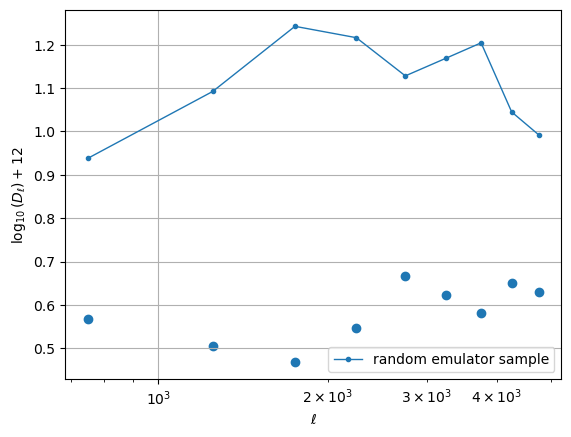

In [303]:
def as_numpy_plot(values):
    if hasattr(values, "detach"):
        return values.detach().cpu().numpy()
    return np.asarray(values)


# obs_noisy_plot = as_numpy_plot(prepared["x_observed_noisy_log10"])
# obs_mean_plot = as_numpy_plot(prepared["x_observed_log10"])
train_plot = as_numpy_plot(prepared["x_gp"][2443])

# plt.plot(ell_np, obs_mean_plot+12, marker="o", ms=3, lw=1.2, label="Battaglia12")
# plt.plot(ell_np, obs_noisy_plot +12, marker="o", ms=3, lw=1.0, label="Battaglia12 noisy")
plt.plot(ell_np, train_plot+12, marker="o", ms=3, lw=1.0, label="random emulator sample")

plt.scatter(ell_np, x_o)
plt.xscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\log_{10}(D_\ell)+12$")
plt.grid()
plt.legend()


In [215]:
ell_np

array([2.0000e+00, 3.0000e+00, 4.0000e+00, 5.0000e+00, 6.0000e+00,
       7.5000e+00, 9.5000e+00, 1.2000e+01, 1.5500e+01, 1.9500e+01,
       2.4500e+01, 3.1000e+01, 3.9500e+01, 5.0500e+01, 6.4000e+01,
       8.1000e+01, 1.0250e+02, 1.3000e+02, 1.6500e+02, 2.0950e+02,
       2.6600e+02, 3.3800e+02, 4.2900e+02, 5.4400e+02, 6.9050e+02,
       8.7650e+02, 1.1125e+03, 1.4120e+03, 1.7920e+03, 2.2740e+03,
       2.8855e+03, 3.6620e+03], dtype=float32)

In [216]:
# np.save("prepared_sbi_dataset_fid_bin32_noise15p.npy", obs_noisy_plot)

## Run SBI On The 512 Dataset

`USE_GAUSSIAN_BEAM_512` selects whether the no-beam or Gaussian-beam data vector is used for both training and observation.


In [217]:
prepared["prior"]

BoxUniform(Uniform(low: torch.Size([9]), high: torch.Size([9])), 1)

In [313]:
from sbi.inference import NLE

seed = 42
torch.manual_seed(seed)

# choose sbi method and train
inference = NLE(prior=prepared["prior"])
density_estimator = inference.append_simulations(
    prepared["theta"][:30000],
    prepared["x"][:30000],
).train(stop_after_epochs=35)

# do inference given observed data
# x_o = prepared["x_observed_noisy_log10"]
x_o = obs_mean_dl_source
posterior = inference.build_posterior(density_estimator)
samples = posterior.sample((100000,), x=x_o)


 Neural network successfully converged after 155 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/105000 [00:00<?, ?it/s]

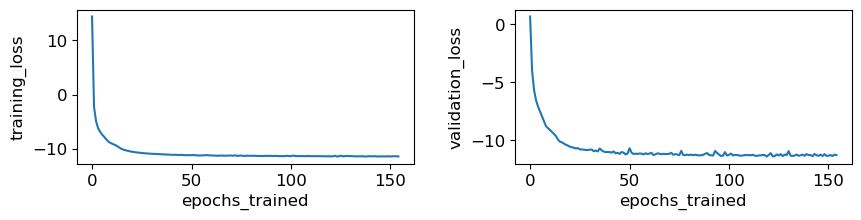

In [314]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [80]:
samples = posterior.sample((200000,), x=x_o)


  0%|          | 0/200000 [00:00<?, ?it/s]

In [ ]:
posterior_save_path = r"outputs\posteriors\posterior_12e3train_N6e4_emulator_noise_sample_binned9_s42_xoSPT.npy"
np.save(posterior_save_path, samples)

In [18]:
prepared["param_names"]

['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

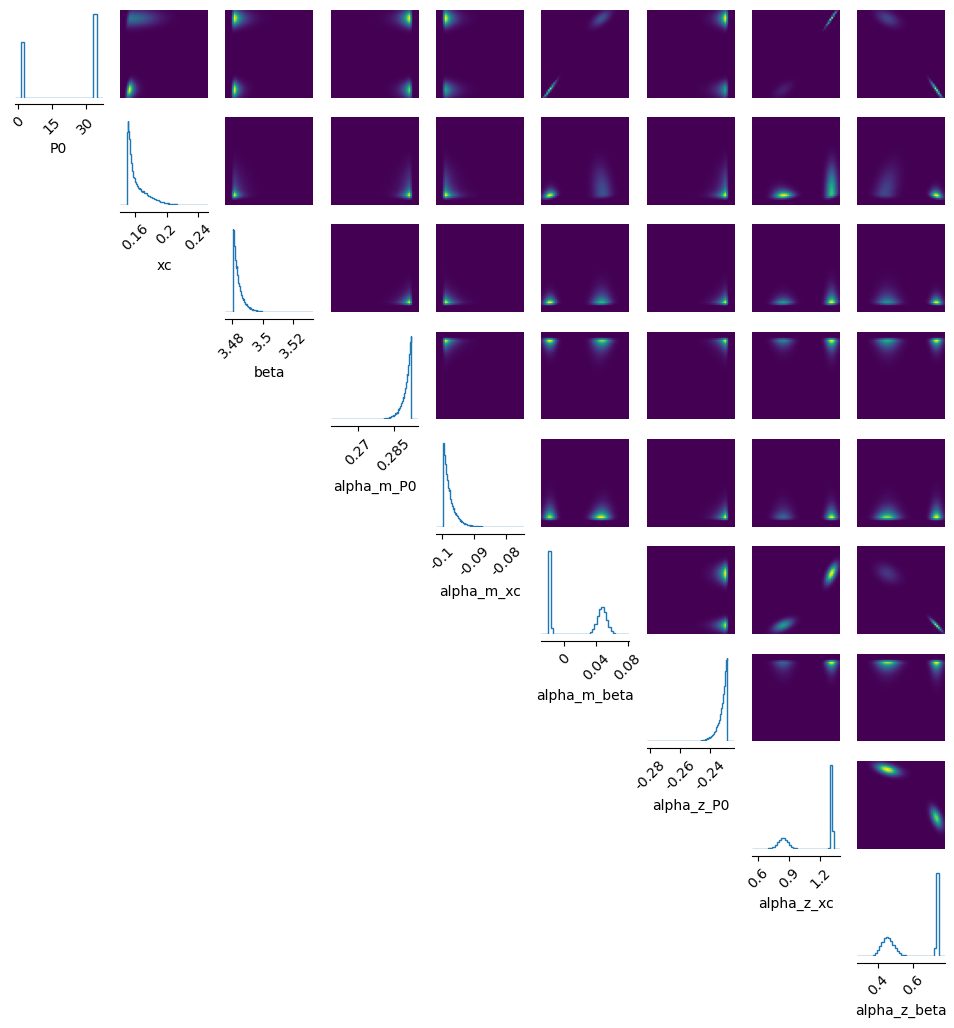

In [316]:
from matplotlib.ticker import MaxNLocator
theta_true = torch.as_tensor(np.array([true_params])).detach().cpu()


fig, axes = pairplot(
    samples,
    labels=prepared["param_names"],
    # points=theta_true,
    figsize = (12, 12),
    upper="kde",
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        # Rotate all x tick labels
        ax.tick_params(axis="x", labelrotation=45)


        # Use fewer ticks everywhere
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

# Specifically enforce 3 x-ticks on diagonal histograms
for i in range(n_params):
    ax = axes[i, i]
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.tick_params(axis="x", labelrotation=45)

plt.savefig("pairplot_N3e4_NLE_constraints_bins9_obsSPT_noGB.png", dpi=300)
plt.show()

In [315]:
posterior_np = samples.detach().cpu().numpy()
param_names = list(prepared["param_names"])

true_values = np.asarray(prepared.get("theta_true", theta_true), dtype=float).reshape(-1)

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
})
print(summary)

summary["median - true"] = summary["median"] - summary["true"]
summary["mean - true"] = summary["mean"] - summary["true"]
summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

pretty = summary.copy()
pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)

pretty = pretty[
    [
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]
]

display(
    pretty.style
    .format({
        "true": "{:.5g}",
        "mean": "{:.5g}",
        "median": "{:.5g}",
        "std": "{:.5g}",
        "median - true": "{:+.5g}",
        "pull": "{:+.2f}",
    })
    .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
)

      parameter      true       mean     median        std       q16  \
0            P0  18.10000  21.299749  34.191658  15.873277  1.845436   
1            xc   0.49700   0.162649   0.157903   0.012804  0.151616   
2          beta   4.35000   3.483784   3.483100   0.003991  3.481242   
3    alpha_m_P0   0.15400   0.289794   0.290574   0.002494  0.287801   
4    alpha_m_xc  -0.00865  -0.097685  -0.098303   0.002030 -0.099364   
5  alpha_m_beta   0.03930   0.020956   0.041968   0.032936 -0.019453   
6    alpha_z_P0  -0.75800  -0.232567  -0.231417   0.003763 -0.235678   
7    alpha_z_xc   0.73100   1.120945   1.307583   0.234371  0.824073   
8  alpha_z_beta   0.41500   0.568950   0.488388   0.145178  0.429166   

         q84      q2.5      q97.5  
0  34.315639  1.834210  34.337780  
1   0.175723  0.150232   0.195742  
2   3.487484  3.480721   3.495147  
3   0.291830  0.283109   0.292189  
4  -0.095982 -0.099667  -0.092189  
5   0.051231 -0.019874   0.057623  
6  -0.229485 -0.242704  -0.

,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P0,18.1,21.3,34.192,15.873,"[1.845, 34.32]","[1.834, 34.34]",+16.092,+1.01,True,True
1,xc,0.497,0.16265,0.1579,0.012804,"[0.1516, 0.1757]","[0.1502, 0.1957]",-0.3391,-26.48,False,False
2,beta,4.35,3.4838,3.4831,0.0039907,"[3.481, 3.487]","[3.481, 3.495]",-0.8669,-217.23,False,False
3,alpha_m_P0,0.154,0.28979,0.29057,0.0024943,"[0.2878, 0.2918]","[0.2831, 0.2922]",+0.13657,+54.75,False,False
4,alpha_m_xc,-0.00865,-0.097685,-0.098303,0.0020298,"[-0.09936, -0.09598]","[-0.09967, -0.09219]",-0.089653,-44.17,False,False
5,alpha_m_beta,0.0393,0.020956,0.041968,0.032936,"[-0.01945, 0.05123]","[-0.01987, 0.05762]",+0.0026685,+0.08,True,True
6,alpha_z_P0,-0.758,-0.23257,-0.23142,0.0037635,"[-0.2357, -0.2295]","[-0.2427, -0.2289]",+0.52658,+139.92,False,False
7,alpha_z_xc,0.731,1.1209,1.3076,0.23437,"[0.8241, 1.313]","[0.761, 1.314]",+0.57658,+2.46,False,False
8,alpha_z_beta,0.415,0.56895,0.48839,0.14518,"[0.4292, 0.7445]","[0.3905, 0.7457]",+0.073388,+0.51,False,True


In [351]:
#### GetDist plotting
import getdist
from getdist import MCSamples, plots

Removed no burn in


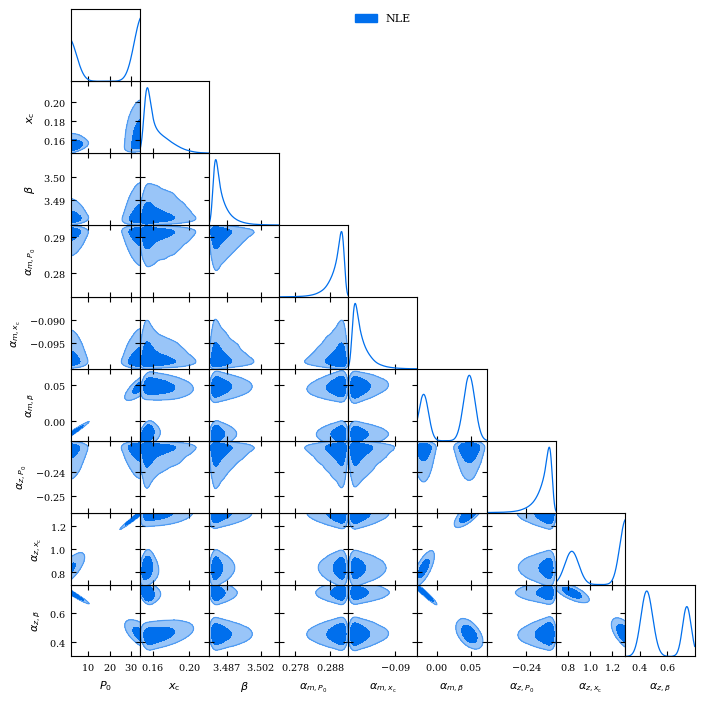

In [357]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

# -----------------------------
# Convert posterior samples
# -----------------------------
if isinstance(samples, torch.Tensor):
    samples_np = samples.detach().cpu().numpy()
else:
    samples_np = np.asarray(samples)

n_params = samples_np.shape[1]

# -----------------------------
# A&A-compatible labels
# -----------------------------
names = [f"p{i}" for i in range(n_params)]

labels = [
    r"P_0",
    r"x_{\rm c}",
    r"\beta",
    r"\alpha_{m,P_0}",
    r"\alpha_{m,x_{\rm c}}",
    r"\alpha_{m,\beta}",
    r"\alpha_{z,P_0}",
    r"\alpha_{z,x_{\rm c}}",
    r"\alpha_{z,\beta}",
][:n_params]

gd_samples = MCSamples(
    samples=samples_np,
    names=names,
    labels=labels,
    label=r"NLE"
)

# -----------------------------
# Settings for non-Gaussian SBI posteriors
# -----------------------------
gd_samples.updateSettings({
    "smooth_scale_1D": 0.3,
    "smooth_scale_2D": 0.3,
    "fine_bins": 2048,
    "fine_bins_2D": 1024,
})

# -----------------------------
# A&A figure style
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

# A&A double-column width: ~18 cm
double_col_width_in = 18.0 / 2.54

g = plots.get_subplot_plotter(width_inch=double_col_width_in)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 8
g.settings.alpha_filled_add = 0.75
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

g.triangle_plot(
    [gd_samples],
    params=names,
    filled=True,
    legend_labels=[r"NLE"],
    contour_lws=[0.9],
    diag1d_kwargs={"linewidth": 1.0},
)

# plt.savefig("triangle_NLE_AA.pdf", dpi=300)
plt.savefig("triangle_NLE_AA.png", dpi=300)
plt.show()

## Dependence on dataset


In [21]:
import torch
import pandas as pd

def posterior_summary(samples, param_names=None):
    """
    samples: torch.Tensor or np.ndarray with shape (N_samples, N_params)
    """

    if not torch.is_tensor(samples):
        samples = torch.as_tensor(samples)

    samples = samples.detach().cpu()

    n_params = samples.shape[1]

    if param_names is None:
        param_names = [f"theta_{i}" for i in range(n_params)]

    mean = samples.mean(dim=0)
    median = samples.median(dim=0).values
    var = samples.var(dim=0, unbiased=True)
    std = samples.std(dim=0, unbiased=True)

    # Equal-tailed credible intervals
    ci68 = torch.quantile(samples, torch.tensor([0.16, 0.84]), dim=0)
    ci95 = torch.quantile(samples, torch.tensor([0.025, 0.975]), dim=0)

    summary = pd.DataFrame({
        "mean": mean.numpy(),
        "median": median.numpy(),
        "variance": var.numpy(),
        "std": std.numpy(),
        "68% lower": ci68[0].numpy(),
        "68% upper": ci68[1].numpy(),
        "95% lower": ci95[0].numpy(),
        "95% upper": ci95[1].numpy(),
    }, index=param_names)

    return summary


In [31]:
dataset_number = [4096, 2048, 1024, 512, 256, 128, 64]
# choose sbi method and train

x_o = prepared["x_observed_noisy_log10"]

dict_for_number = {}

for number_data in dataset_number:
    inference = NPE(prior=prepared["prior"])
    density_estimator_temp = inference.append_simulations(
        prepared["theta"][:number_data],
        prepared["x"][:number_data],
    ).train()

    # do inference given observed data
    posterior = inference.build_posterior(density_estimator_temp)
    samples = posterior.sample((10000,), x=x_o)

    posterior_summary_df = posterior_summary(samples, param_names=prepared["param_names"])
    dict_for_number[number_data] = [posterior_summary_df, samples]


 Neural network successfully converged after 195 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 130 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 153 epochs.

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 195 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 179 epochs.

  0%|          | 0/10000 [00:00<?, ?it/s]

In [32]:
std_dataset = []
for numb in dataset_number:
    std_dataset.append(dict_for_number[numb][0]["std"]) 
std_dataset = np.array(std_dataset)

In [33]:
mean_dataset = []
for numb in dataset_number:
    mean_dataset.append(dict_for_number[numb][0]["mean"])
mean_dataset = np.array(mean_dataset)

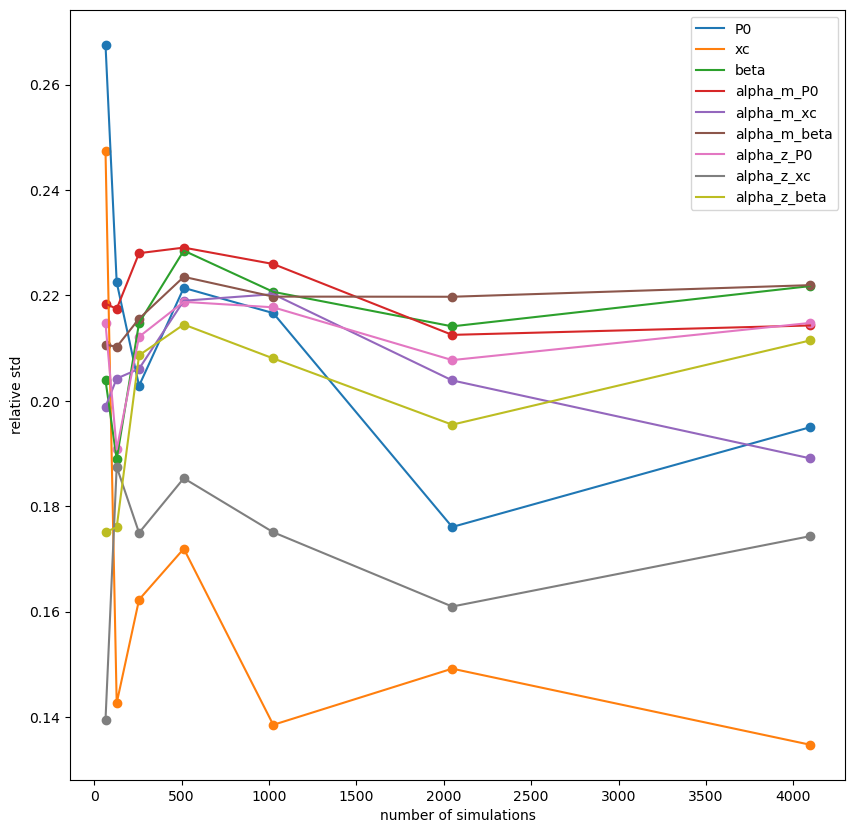

In [38]:
plt.figure(figsize=(10, 10))

for i, param_name in enumerate(prepared["param_names"]):
    Delta_param = SOBOL_PRIOR_BOUNDS[param_name][1] - SOBOL_PRIOR_BOUNDS[param_name][0]
    plt.plot(dataset_number, abs(std_dataset[:,i]/Delta_param), label = param_name)
    plt.scatter(dataset_number, abs(std_dataset[:,i]/Delta_param))
# plt.yscale("log")
plt.legend()
plt.xlabel("number of simulations")
plt.ylabel("relative std")
plt.savefig("../plots/SBI_plots/relative_std_vs_number_simulations_max4096_fixed_noisy.png", dpi=300)
plt.show()

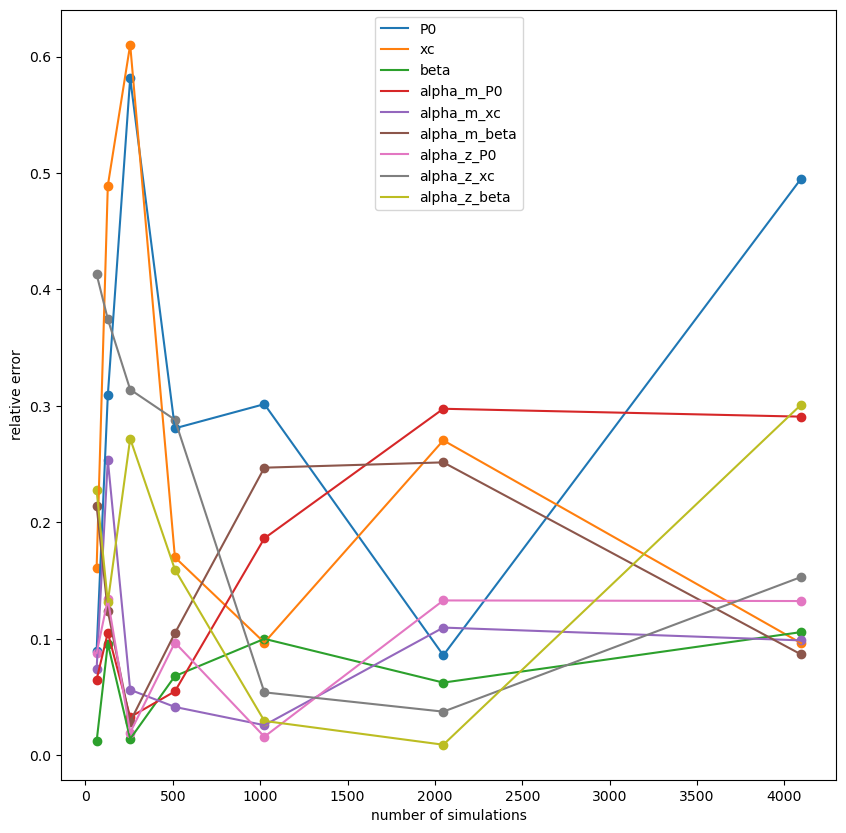

In [37]:
plt.figure(figsize=(10, 10))

for i, param_name in enumerate(prepared["param_names"]):
    plt.plot(dataset_number, abs((mean_dataset[:,i] - np.array(theta_true)[0][i])/std_dataset[:,i]), label = param_name)
    plt.scatter(dataset_number, abs((mean_dataset[:,i] - np.array(theta_true)[0][i])/std_dataset[:,i]))
# plt.yscale("log")
plt.legend()
plt.xlabel("number of simulations")
plt.ylabel("relative error")
plt.savefig("../plots/SBI_plots/relative_error_vs_number_simulations_max4096_fixed_noisy.png", dpi=300)
plt.show()

In [28]:
theta_true

tensor([[ 1.8100e+01,  4.9700e-01,  4.3500e+00,  1.5400e-01, -8.6500e-03,
          3.9300e-02, -7.5800e-01,  7.3100e-01,  4.1500e-01]],
       dtype=torch.float64)

# Generating the "observed" function

In [103]:
samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")

sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:1: SyntaxWarning: invalid escape sequence '\p'
  samples_noisy = np.load("outputs\posteriors\posterior_100_000_emulator_sample_noisy_binned32.npy")
C:\Users\kn18001\AppData\Local\Temp\ipykernel_30940\38969436.py:3: SyntaxWarning: invalid escape sequence '\p'
  sample_noisy_4096 = np.load("outputs\posteriors\posterior_4096_sample_noisy_binned32.npy")


In [92]:
noisy_sample.shape

(200000, 9)

In [97]:
from matplotlib.ticker import MaxNLocator
import numpy as np
import torch
import matplotlib.pyplot as plt

theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean = samples.detach().cpu()


samples_noisy = torch.as_tensor(
    samples_noisy,
    dtype=torch.float32
).detach().cpu()
# 4096 noisy samples already available as numpy
samples_4096_noisy = torch.as_tensor(
    sample_noisy_4096,
    dtype=torch.float32
).detach().cpu()

all_samples = [
    samples_clean,
    samples_noisy,
    samples_4096_noisy,
]

sample_labels = [
    "clean 1024",
    "noisy 1024",
    "noisy 4096",
]

In [98]:
combined = np.vstack([s.numpy() for s in all_samples])

limits = []
for i in range(combined.shape[1]):
    lo, hi = np.percentile(combined[:, i], [0.5, 99.5])
    pad = 0.05 * (hi - lo)
    limits.append([lo - pad, hi + pad])

In [104]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
import numpy as np
import torch
import matplotlib.pyplot as plt

def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def contour_levels_from_hist(H, probs=(0.68, 0.95)):
    Hflat = H.ravel()
    Hflat = Hflat[np.isfinite(Hflat)]
    Hsort = np.sort(Hflat)[::-1]

    cumsum = np.cumsum(Hsort)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        idx = np.searchsorted(cumsum, p)
        idx = min(idx, len(Hsort) - 1)
        levels.append(Hsort[idx])

    return sorted(levels)

def add_contours(ax, samples_np, ix, iy, limits, color, bins=60, smooth=1.0):
    x = samples_np[:, ix]
    y = samples_np[:, iy]

    H, xedges, yedges = np.histogram2d(
        x, y,
        bins=bins,
        range=[limits[ix], limits[iy]],
        density=True
    )

    H = gaussian_filter(H, smooth)

    if not np.any(np.isfinite(H)) or np.nanmax(H) <= 0:
        return

    levels = contour_levels_from_hist(H, probs=(0.68, 0.95))

    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        H.T,
        levels=levels,
        colors=[color],
        linewidths=1.3,
        alpha=0.95,
        zorder=5
    )

In [108]:
theta_true = torch.as_tensor(
    np.array([true_params]),
    dtype=torch.float32
).detach().cpu()

samples_clean_np = to_numpy(samples)
samples_noisy_np = to_numpy(samples_noisy)
samples_4096_noisy_np = np.asarray(sample_noisy_4096)

datasets = [
    ("emulator", samples_clean_np),
    ("noisy emulator", samples_noisy_np),
    ("noisy 4096", samples_4096_noisy_np),
]

colors = {
    "emulator": "C0",
    "noisy emulator": "C1",
    "noisy 4096": "C2",
}

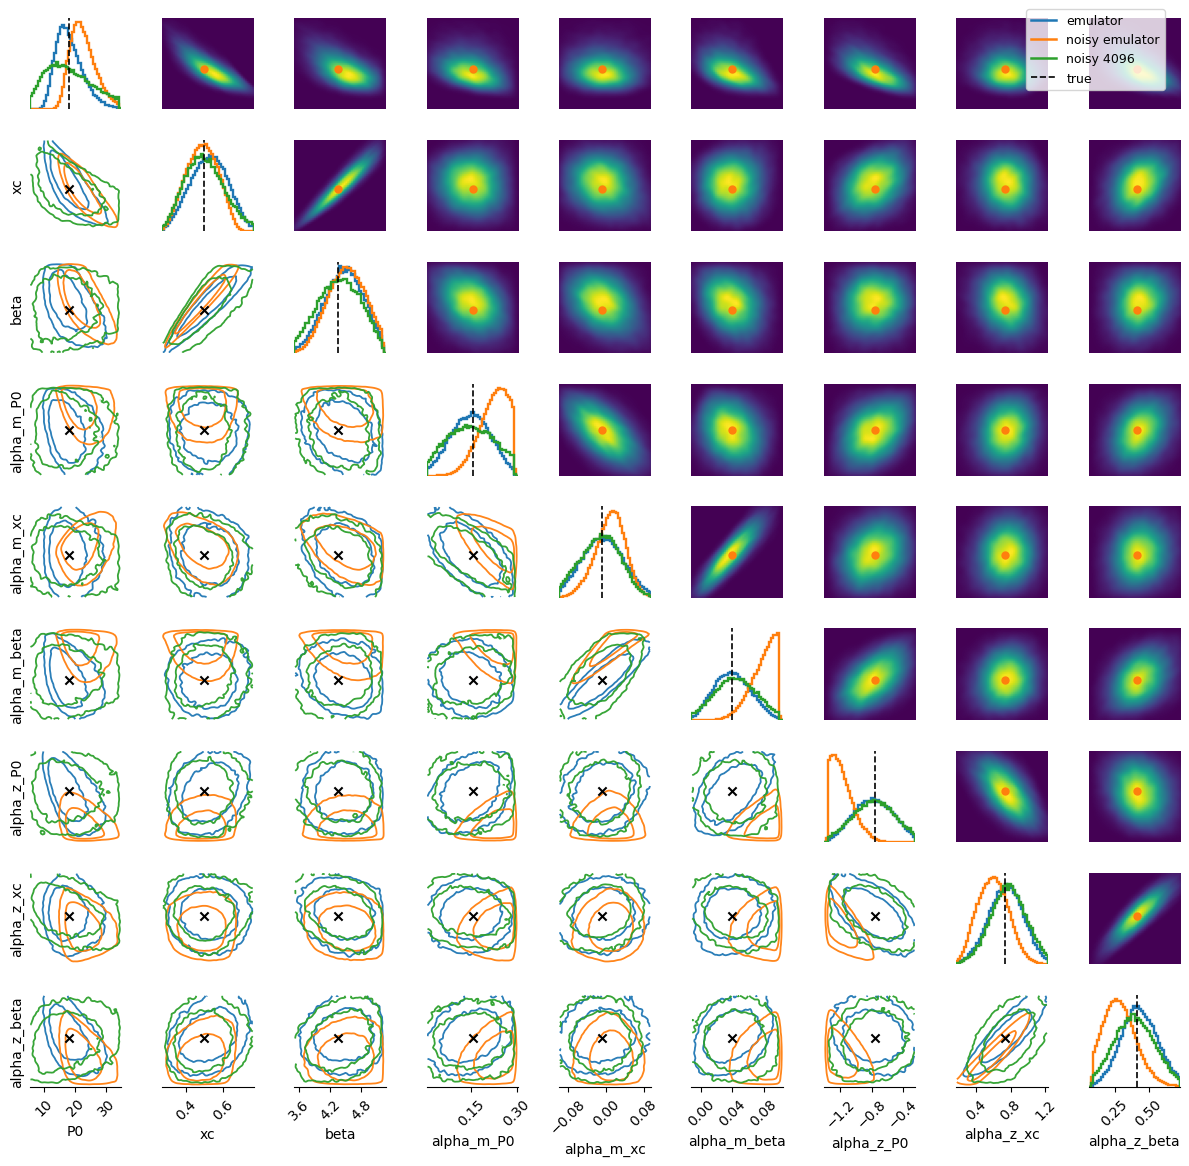

In [114]:
param_names = prepared["param_names"]
n_params = len(param_names)

fig, axes = pairplot(
    torch.as_tensor(samples_clean_np, dtype=torch.float32),
    labels=param_names,
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",       # only clean samples in upper triangle
    lower="contour",   # will be cleared below
    diag="hist",       # will be cleared below
)

axes = np.asarray(axes)

# Clear diagonal and lower triangle so we control them manually
for i in range(n_params):
    for j in range(n_params):
        if i >= j:
            axes[i, j].clear()

for i in range(n_params):
    ax = axes[i, i]

    for name, data in datasets:
        ax.hist(
            data[:, i],
            bins=45,
            range=limits[i],
            density=True,
            histtype="step",
            linewidth=1.7,
            color=colors[name],
            zorder=5,
        )

    # true value
    ax.axvline(
        true_params[i],
        color="k",
        linestyle="--",
        linewidth=1.2,
        zorder=6,
    )

    ax.set_xlim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        if i > j:
            ax = axes[i, j]

            for name, data in datasets:
                add_contours(
                    ax,
                    data,
                    ix=j,
                    iy=i,
                    limits=limits,
                    color=colors[name],
                    bins=60,
                    smooth=1.0,
                )

            # true point
            ax.scatter(
                true_params[j],
                true_params[i],
                color="k",
                marker="x",
                s=35,
                zorder=10,
            )

            ax.set_xlim(limits[j])
            ax.set_ylim(limits[i])

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

        # only outer labels
        if i == n_params - 1:
            ax.set_xlabel(param_names[j])
        else:
            ax.set_xlabel("")

        if j == 0 and i > 0:
            ax.set_ylabel(param_names[i])
        else:
            ax.set_ylabel("")

# One global legend only
legend_handles = [
    Line2D([0], [0], color=colors["emulator"], lw=1.8, label="emulator"),
    Line2D([0], [0], color=colors["noisy emulator"], lw=1.8, label="noisy emulator"),
    Line2D([0], [0], color=colors["noisy 4096"], lw=1.8, label="noisy 4096"),
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="true"),
]

fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
plt.savefig("pairplot_clean_kde_all_hists_all_contours.png", dpi=300)
plt.show()

In [112]:
os.getcwd()

'\\\\wsl.localhost\\myrootfs\\home\\cbllover\\HalfDome\\SBI_analysis'

In [ ]:
fig, axes = pairplot(
    datasets,
    labels=prepared["param_names"],
    points=theta_true,
    limits=limits,
    figsize=(12, 12),
    upper="kde",
    lower="contour",
    diag="hist",
    samples_labels=sample_labels,
)

axes = np.asarray(axes)
n_params = axes.shape[0]

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]

        ax.tick_params(axis="x", labelrotation=45)
        ax.xaxis.set_major_locator(MaxNLocator(3))
        ax.yaxis.set_major_locator(MaxNLocator(3))

plt.tight_layout()
plt.savefig("pairplot_clean_noisy_4096_contours.png", dpi=300)
plt.show()